In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [5]:
ks, _, iGarr = gvectors("./LDA/BN44BC-0.0");
iGarr_gamma = np.array(iGarr[1]);

In [ ]:
Ckb = return_cg("./LDA/BN44BC-0.0", ks, iGarr, [0, 0, 0], 65, 128, Val('u'));

In [51]:
wfn = JJDFTX.real_space_wfn(Ckb, iGarr_gamma, [80, 80, 168])
wfn_squared = (abs.(wfn)).^2
wfn_squared *= length(wfn_squared); # Make it so wfn squared is probability density at each point

In [58]:
sum(wfn_squared)*12333.2/length(wfn_squared)

0.9999977157817516

In [52]:
splits = Float64[]
x = Float64[]
for i in 1:41
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)

    filename_eigenvals = "./LDA/BN44BC-$(charge).eigenvals"
    
    filename_nup = "./LDA/BN44BC-$(charge).n_up"
    
    filename_ndn = "./LDA/BN44BC-$(charge).n_dn"
    
    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)
        
    n_up = np.reshape(n_up, [80, 80, 168])
    n_dn = np.reshape(n_dn, [80, 80, 168])

    diff = abs(sum((n_up.^(1/3) - n_dn.^(1/3)).*wfn_squared))*12333.2/length(n_dn)

    push!(x, diff)
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 128, 19, spin=2);
    push!(splits, abs(mean(data[2][65]) - mean(data[1][65])))
end

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41


In [53]:
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = true;

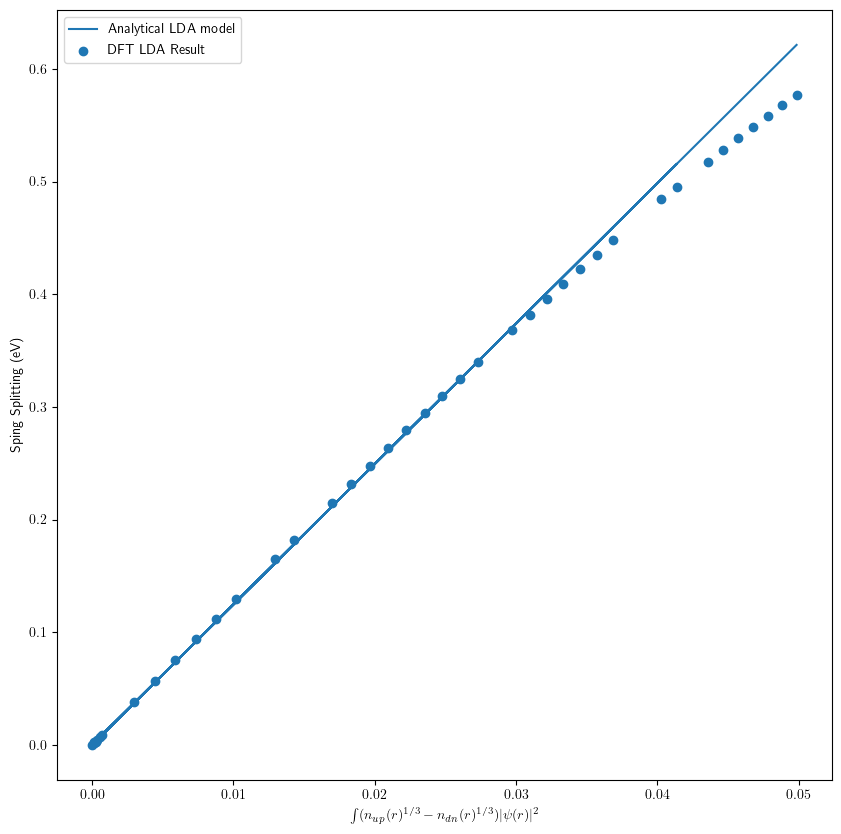

PyObject <matplotlib.legend.Legend object at 0x7f2b555ff7c0>

In [54]:
figure(figsize=(10, 10))
scatter(x, splits, label="DFT LDA Result")

plot(x, x*0.458*1/eV, label="Analytical LDA model")
ylabel("Sping Splitting (eV)")

xlabel(L"\int (n_{up}(r)^{1/3}-n_{dn}(r)^{1/3})|\psi(r)|^2")
legend()

In [52]:
charge = -1.0
    
filename_nup = "./LDA/BN44BC-$(charge).n_up"
n_up = np.fromfile(filename_nup)



1075200-element Vector{Float64}:
 0.014548213100843753
 0.04280604503192602
 0.0893990857251949
 0.10242183150843234
 0.08259662509386176
 0.05595565789735678
 0.03599351791128678
 0.022905802111313694
 0.014083191154778484
 0.00840549119550053
 0.005146452203778406
 0.0032579864373538797
 0.0019767090658909937
 ⋮
 0.001955862619615274
 0.003208451096671191
 0.005073119084379701
 0.008307178634183916
 0.013944881224040475
 0.022666065736471775
 0.03541271408647469
 0.054629665563123014
 0.08080174174666781
 0.10331312725392174
 0.10025804073549419
 0.06877610809208881

In [53]:
sum(n_up)*12333.2/length(n_up)

63.999853810001305

In [21]:
64+64

128

In [23]:
sum(wfn_squared)*12333.2

0.9999977157817516